# Steam : analyse du marché des jeux vidéo (PySpark + Databricks)

Ubisoft veut sortir un nouveau jeu et demande une analyse globale des jeux disponibles sur Steam, pour comprendre l'écosystème et les tendances.

Données : `steam_game_output.json` (55 691 entrées, une par jeu, au format JSON imbriqué).

Plan :
1. Lecture et préparation des données (PySpark)
2. Analyse « macro » : éditeurs, notes, sorties par année, prix et remises, langues, âge minimum
3. Analyse des genres : fréquence, avis, éditeurs, revenus estimés
4. Analyse des plateformes : Windows, Mac, Linux
5. Conclusion

Les graphiques sont créés avec l'outil de visualisation de Databricks (bouton + à côté de l'onglet Table sous chaque résultat).

## 1. Lecture et préparation des données

In [0]:
from pyspark.sql import functions as F

filepath = "s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json"
raw = spark.read.json(filepath)
print("Nombre d'entrées :", raw.count())

Nombre d'entrées : 55691


Le JSON est imbriqué : tout est dans la colonne `data` (un struct). On la déplie avec `select("data.*")`. La colonne `tags` contient un champ par tag Steam (plus de 400) : on la met de côté, elle n'est pas utilisée ici.

In [0]:
games_raw = raw.select("data.*").drop("tags")
print("Colonnes :", games_raw.columns)
games_raw.groupBy("type").count().show()

Colonnes : ['appid', 'categories', 'ccu', 'developer', 'discount', 'genre', 'header_image', 'initialprice', 'languages', 'name', 'negative', 'owners', 'platforms', 'positive', 'price', 'publisher', 'release_date', 'required_age', 'short_description', 'type', 'website']
+--------+-----+
|    type|count|
+--------+-----+
|hardware|    1|
|    game|55690|
+--------+-----+



Le jeu de données contient aussi du matériel (`hardware`) : on garde uniquement les jeux (`type = game`).

Les prix, les dates, les remises et le nombre de propriétaires sont stockés sous forme de texte. On les convertit :
- `price` et `initialprice` : prix en centimes, convertis en unités (prix actuel et prix avant remise ; la devise n'est pas précisée dans les données)
- `release_date` : texte `2000/11/1`, converti en date
- `discount` : pourcentage de remise
- `owners` : fourchette de propriétaires (par exemple `10,000,000 .. 20,000,000`), qu'on sépare en minimum, maximum et milieu de fourchette
- `required_age` : valeurs hétérogènes (`16`, `21+`, `MA 15+`…), dont on extrait le nombre
- `positive` et `negative` : nombre d'avis positifs et négatifs, d'où un taux d'avis positifs

In [0]:
owners_parts = F.split(F.col("owners"), r" \.\. ")

games = (
    games_raw
    .filter(F.col("type") == "game")
    .withColumn("release_date", F.expr("try_to_date(release_date, 'yyyy/M/d')"))
    .withColumn("release_year", F.year("release_date"))
    .withColumn("price_amount", F.expr("try_cast(price AS DOUBLE)") / 100)
    .withColumn("initial_price", F.expr("try_cast(initialprice AS DOUBLE)") / 100)
    .withColumn("discount_pct", F.expr("try_cast(discount AS INT)"))
    .withColumn("owners_min_txt", F.regexp_replace(owners_parts.getItem(0), ",", ""))
    .withColumn("owners_max_txt", F.regexp_replace(owners_parts.getItem(1), ",", ""))
    .withColumn("owners_min", F.expr("try_cast(owners_min_txt AS BIGINT)"))
    .withColumn("owners_max", F.expr("try_cast(owners_max_txt AS BIGINT)"))
    .withColumn("owners_mid", (F.col("owners_min") + F.col("owners_max")) / 2)
    .withColumn("age_txt", F.regexp_extract("required_age", r"(\d+)", 1))
    .withColumn("age", F.expr("try_cast(age_txt AS INT)"))
    .withColumn("n_reviews", F.col("positive") + F.col("negative"))
    .withColumn("positive_ratio", F.when(F.col("n_reviews") > 0, F.col("positive") / F.col("n_reviews")))
    .drop("owners_min_txt", "owners_max_txt", "age_txt")
)
print("Nombre de jeux :", games.count())

Nombre de jeux : 55690


In [0]:
display(games.select("name", "publisher", "genre", "release_date", "price_amount", "initial_price", "discount_pct", "owners_min", "owners_max", "age", "positive", "negative", "positive_ratio").limit(10))

name,publisher,genre,release_date,price_amount,initial_price,discount_pct,owners_min,owners_max,age,positive,negative,positive_ratio
Counter-Strike,Valve,Action,2000-11-01,9.99,9.99,0,10000000,20000000,0,201215,5199,0.9748127549487923
ASCENXION,PsychoFlux Entertainment,"Action, Adventure, Indie",2021-05-14,9.99,9.99,0,0,20000,0,27,5,0.84375
Crown Trick,"Team17, NEXT Studios","Adventure, Indie, RPG, Strategy",2020-10-16,5.99,19.99,70,200000,500000,0,4032,646,0.8619067977768277
"Cook, Serve, Delicious! 3?!",Vertigo Gaming Inc.,"Action, Indie, Simulation, Strategy",2020-10-14,19.99,19.99,0,100000,200000,0,1575,115,0.9319526627218935
细胞战争,DoubleC Games,"Action, Casual, Indie, Simulation",2019-03-30,1.99,1.99,0,0,20000,0,0,1,0.0
Zengeon,2P Games,"Action, Adventure, Indie, RPG",2019-06-24,7.99,19.99,60,100000,200000,0,1018,462,0.6878378378378378
干支セトラ 陽ノ卷｜干支etc. 陽之卷,Starship Studio,"Adventure, Indie, RPG, Strategy",2019-01-24,12.99,12.99,0,0,20000,0,18,6,0.75
Jumping Master(跳跳大咖),重庆环游者网络科技,"Action, Adventure, Casual, Free to Play, Massively Multiplayer",2019-04-08,0.0,0.0,0,20000,50000,0,50,34,0.5952380952380952
Cube Defender,Simon Codrington,"Casual, Indie",2019-01-06,2.99,2.99,0,0,20000,0,6,0,1.0
Tower of Origin2-Worm's Nest,Villain Role,"Indie, RPG",2021-09-09,13.99,13.99,0,0,20000,0,32,12,0.7272727272727273


Contrôle de la qualité : valeurs manquantes sur les colonnes utilisées.

In [0]:
cols = ["name", "publisher", "genre", "release_date", "price_amount", "owners_mid", "age", "positive_ratio", "languages"]
display(games.select([F.sum(F.when(F.col(c).isNull() | (F.col(c) == ""), 1).otherwise(0)).alias(c) if c in ("name", "publisher", "genre", "languages") else F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in cols]))

name,publisher,genre,release_date,price_amount,owners_mid,age,positive_ratio,languages
0,132,160,222,0,0,0,163,10


## 2. Analyse « macro »

### Quel éditeur a sorti le plus de jeux ?

Un éditeur est pris tel qu'il est écrit dans la colonne `publisher` (certains jeux ont plusieurs éditeurs, séparés par une virgule : ils sont comptés comme un ensemble).

Visualisation à créer : barres, axe X = `publisher`, axe Y = `n_games`.

In [0]:
top_publishers = (
    games.filter(F.col("publisher").isNotNull() & (F.col("publisher") != ""))
    .groupBy("publisher").agg(F.count("*").alias("n_games"))
    .orderBy(F.desc("n_games")).limit(15)
)
display(top_publishers)

publisher,n_games
Big Fish Games,422
8floor,202
SEGA,165
Strategy First,151
Square Enix,141
Choice of Games,140
HH-Games,132
Sekai Project,132
Ubisoft,127
Laush Studio,126


Databricks visualization. Run in Databricks to view.

**Nombre de jeux par éditeur (top 15)**

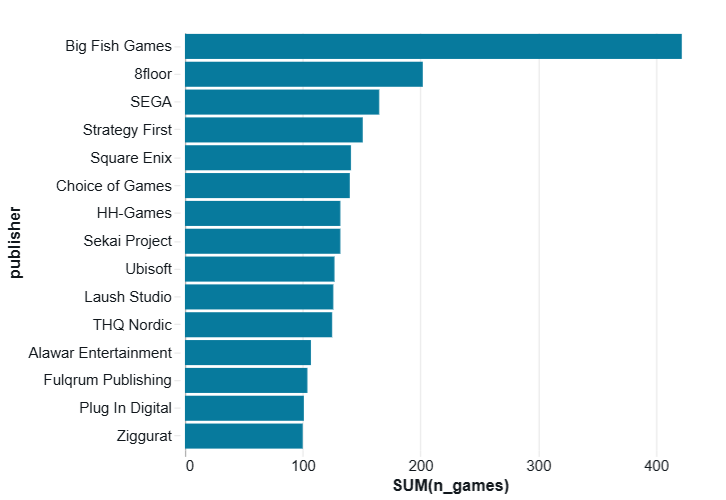

### Quels sont les jeux les mieux notés ?

On calcule le taux d'avis positifs (`positive / (positive + negative)`). Pour éviter qu'un jeu avec 5 avis, tous positifs, arrive en tête, on ne garde que les jeux ayant au moins 10 000 avis.

Visualisation à créer : barres, axe X = `name`, axe Y = `positive_ratio`.

In [0]:
best_rated = (
    games.filter(F.col("n_reviews") >= 10000)
    .select("name", "publisher", "positive", "negative", "n_reviews", F.round("positive_ratio", 3).alias("positive_ratio"))
    .orderBy(F.desc("positive_ratio")).limit(15)
)
display(best_rated)

name,publisher,positive,negative,n_reviews,positive_ratio
A Short Hike,adamgryu,11645,87,11732,0.993
Aseprite,Igara Studio,11823,80,11903,0.993
Senren＊Banka,"HIKARI FIELD, NekoNyan Ltd.",10593,84,10677,0.992
People Playground,Studio Minus,142920,1649,144569,0.989
Portal 2,Valve,305671,3770,309441,0.988
The Room 4: Old Sins,Fireproof Games,10294,130,10424,0.988
Vampire Survivors,poncle,130311,1624,131935,0.988
ULTRAKILL,New Blood Interactive,40050,548,40598,0.987
The Henry Stickmin Collection,Innersloth,32913,427,33340,0.987
Hades,Supergiant Games,199960,2829,202789,0.986


### Y a-t-il des années avec plus de sorties ? Et pendant le Covid ?

Nombre de jeux par année de sortie. Visualisation à créer : ligne, axe X = `release_year`, axe Y = `n_games`.

In [0]:
releases_per_year = (
    games.filter(F.col("release_year").between(2000, 2024))
    .groupBy("release_year").agg(F.count("*").alias("n_games"))
    .orderBy("release_year")
)
display(releases_per_year)

release_year,n_games
2000,2
2001,4
2002,1
2003,3
2004,6
2005,6
2006,61
2007,98
2008,159
2009,309


Databricks visualization. Run in Databricks to view.

**Nombre de jeux sortis par année**

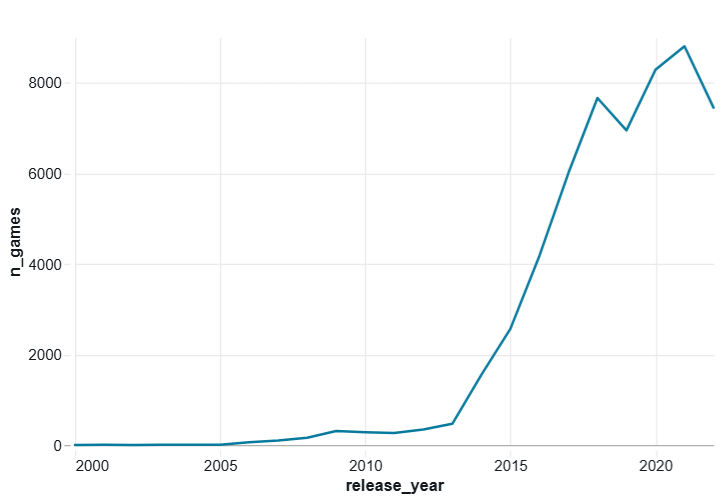

Pour regarder le Covid de plus près : les sorties par mois entre 2018 et 2022. Visualisation à créer : ligne, axe X = `month`, axe Y = `n_games`.

In [0]:
releases_per_month = (
    games.filter(F.col("release_year").between(2018, 2022))
    .withColumn("month", F.date_format("release_date", "yyyy-MM"))
    .groupBy("month").agg(F.count("*").alias("n_games"))
    .orderBy("month")
)
display(releases_per_month)

month,n_games
2018-01,501
2018-02,617
2018-03,745
2018-04,663
2018-05,683
2018-06,594
2018-07,644
2018-08,652
2018-09,652
2018-10,626


### Comment se répartissent les prix ? Y a-t-il beaucoup de jeux en promotion ?

Répartition des jeux par tranche de prix actuel. Visualisation à créer : barres, axe X = `price_range`, axe Y = `n_games`.

In [0]:
price_ranges = (
    games.withColumn(
        "price_range",
        F.when(F.col("price_amount") == 0, "1 - Gratuit")
        .when(F.col("price_amount") < 5, "2 - Moins de 5")
        .when(F.col("price_amount") < 10, "3 - 5 à 10")
        .when(F.col("price_amount") < 20, "4 - 10 à 20")
        .when(F.col("price_amount") < 30, "5 - 20 à 30")
        .when(F.col("price_amount") < 60, "6 - 30 à 60")
        .otherwise("7 - 60 et plus"),
    )
    .filter(F.col("price_amount").isNotNull())
    .groupBy("price_range").agg(F.count("*").alias("n_games"))
    .orderBy("price_range")
)
display(price_ranges)

price_range,n_games
1 - Gratuit,7779
2 - Moins de 5,23478
3 - 5 à 10,12450
4 - 10 à 20,9022
5 - 20 à 30,1794
6 - 30 à 60,1045
7 - 60 et plus,122


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

**Nombre de jeux par tranche de prix**

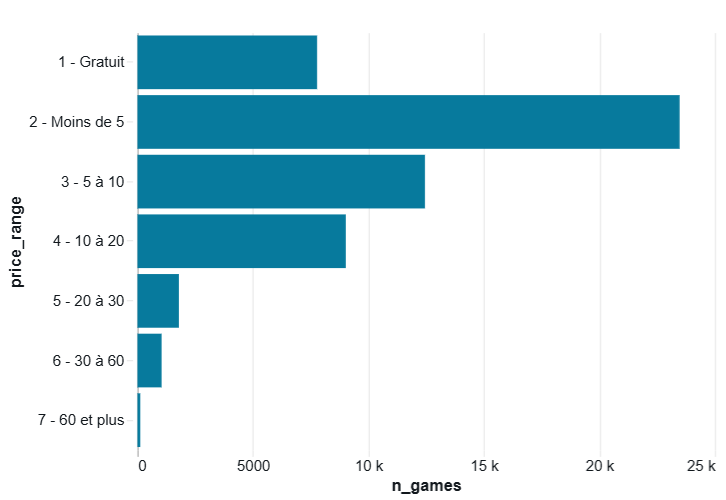

**Répartition des jeux par tranche de prix (camembert)**

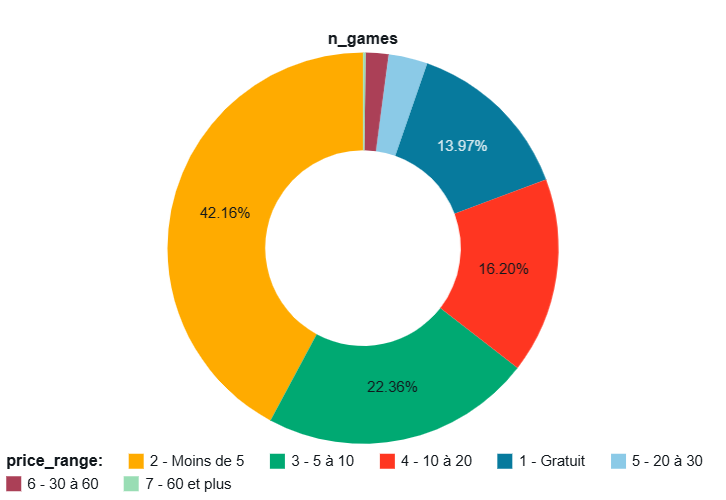

Part des jeux en promotion (remise supérieure à 0 %) et répartition des remises. Visualisation à créer pour la seconde : barres, axe X = `discount_pct`, axe Y = `n_games`.

In [0]:
n_total = games.filter(F.col("discount_pct").isNotNull()).count()
n_discount = games.filter(F.col("discount_pct") > 0).count()
print(f"{n_discount} jeux en promotion sur {n_total}, soit {n_discount / n_total:.1%}")

discounts = (
    games.filter(F.col("discount_pct") > 0)
    .groupBy("discount_pct").agg(F.count("*").alias("n_games"))
    .orderBy("discount_pct")
)
display(discounts)

2518 jeux en promotion sur 55690, soit 4.5%


discount_pct,n_games
10,53
12,1
15,45
18,3
19,1
20,112
21,1
22,6
24,2
25,85


### Quelles sont les langues les plus représentées ?

La colonne `languages` est un texte avec les langues séparées par des virgules : on la découpe avec `split()` puis on met chaque langue sur sa propre ligne avec `explode()`. Visualisation à créer : barres, axe X = `language`, axe Y = `n_games`.

In [0]:
languages = (
    games.filter(F.col("languages").isNotNull())
    .select(F.explode(F.split("languages", ",")).alias("language"))
    .withColumn("language", F.trim(F.regexp_replace("language", r"\*|<[^>]*>|languages with full audio support", "")))
    .filter(F.col("language") != "")
    .groupBy("language").agg(F.count("*").alias("n_games"))
    .orderBy(F.desc("n_games")).limit(15)
)
display(languages)

language,n_games
English,55116
German,14019
French,13426
Russian,12922
Simplified Chinese,12782
Spanish - Spain,12233
Japanese,10368
Italian,9304
Portuguese - Brazil,6750
Korean,6600


### Y a-t-il beaucoup de jeux interdits aux moins de 16 ou 18 ans ?

L'âge minimum (`required_age`) est mal renseigné : on extrait le nombre et on écarte les valeurs impossibles (plus de 21 ans). Visualisation à créer : barres, axe X = `age_group`, axe Y = `n_games`.

In [0]:
age_groups = (
    games.filter(F.col("age").isNotNull() & (F.col("age") <= 21))
    .withColumn(
        "age_group",
        F.when(F.col("age") >= 18, "3 - 18 ans et plus")
        .when(F.col("age") >= 16, "2 - 16 à 17 ans")
        .otherwise("1 - Moins de 16 ans"),
    )
    .groupBy("age_group").agg(F.count("*").alias("n_games"))
    .orderBy("age_group")
)
display(age_groups)

age_group,n_games
1 - Moins de 16 ans,55384
2 - 16 à 17 ans,76
3 - 18 ans et plus,225


In [0]:
valid_age = games.filter(F.col("age").isNotNull() & (F.col("age") <= 21))
n_age = valid_age.count()
print(f"Interdits aux moins de 16 ans : {valid_age.filter(F.col('age') >= 16).count() / n_age:.1%}")
print(f"Interdits aux moins de 18 ans : {valid_age.filter(F.col('age') >= 18).count() / n_age:.1%}")

Interdits aux moins de 16 ans : 0.5%
Interdits aux moins de 18 ans : 0.4%


## 3. Analyse des genres

La colonne `genre` contient plusieurs genres par jeu, séparés par des virgules. On crée une table avec une ligne par couple (jeu, genre) avec `explode()`. Un jeu qui a trois genres compte donc une fois dans chacun.

In [0]:
game_genres = (
    games.filter(F.col("genre").isNotNull() & (F.col("genre") != ""))
    .withColumn("genre", F.explode(F.split("genre", ",")))
    .withColumn("genre", F.trim("genre"))
    .filter(F.col("genre") != "")
)
print("Lignes (jeu, genre) :", game_genres.count())

Lignes (jeu, genre) : 157110


### Quels sont les genres les plus représentés ? Visualisation à créer : barres, axe X = `genre`, axe Y = `n_games`.

In [0]:
genre_counts = game_genres.groupBy("genre").agg(F.count("*").alias("n_games")).orderBy(F.desc("n_games"))
display(genre_counts.limit(15))

genre,n_games
Indie,39681
Action,23759
Casual,22086
Adventure,21431
Strategy,10895
Simulation,10836
RPG,9534
Early Access,6145
Free to Play,3393
Sports,2666


Databricks visualization. Run in Databricks to view.

**Nombre de jeux par genre**

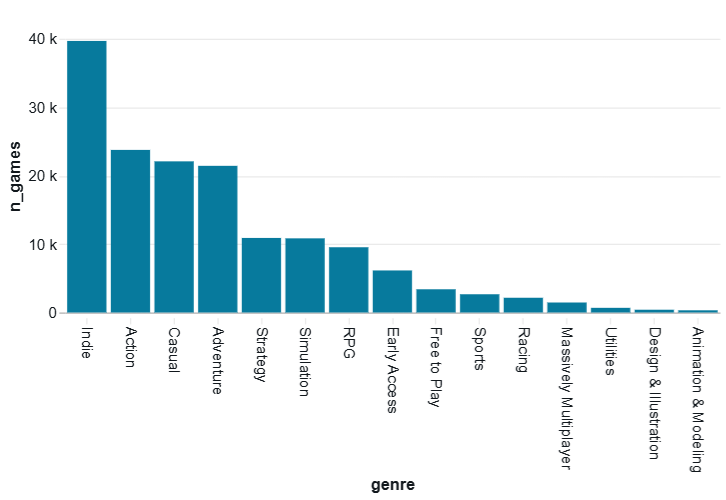

### Quels genres ont le meilleur ratio d'avis positifs ?

On additionne les avis positifs et négatifs de tous les jeux du genre, puis on calcule le ratio. On ne garde que les genres avec au moins 100 jeux. Visualisation à créer : barres, axe X = `genre`, axe Y = `positive_ratio`.

In [0]:
genre_reviews = (
    game_genres.groupBy("genre")
    .agg(F.count("*").alias("n_games"), F.sum("positive").alias("positive"), F.sum("negative").alias("negative"))
    .filter(F.col("n_games") >= 100)
    .withColumn("positive_ratio", F.round(F.col("positive") / (F.col("positive") + F.col("negative")), 3))
    .select("genre", "n_games", "positive_ratio")
    .orderBy(F.desc("positive_ratio"))
)
display(genre_reviews)

genre,n_games,positive_ratio
Photo Editing,105,0.977
Animation & Modeling,322,0.963
Design & Illustration,406,0.961
Utilities,682,0.944
Game Development,159,0.893
Indie,39681,0.885
Audio Production,195,0.88
Video Production,247,0.872
Casual,22086,0.867
Simulation,10836,0.866


### Les éditeurs ont-ils des genres favoris ?

On prend les 8 éditeurs qui ont publié le plus de jeux et on compte leurs jeux par genre. Visualisation à créer : barres empilées, axe X = `publisher`, axe Y = `n_games`, séries (« group by ») = `genre`.

In [0]:
top8 = [r["publisher"] for r in top_publishers.limit(8).collect()]
top_genres = [r["genre"] for r in genre_counts.limit(8).collect()]

publisher_genres = (
    game_genres.filter(F.col("publisher").isin(top8) & F.col("genre").isin(top_genres))
    .groupBy("publisher", "genre").agg(F.count("*").alias("n_games"))
    .orderBy("publisher", F.desc("n_games"))
)
display(publisher_genres)

publisher,genre,n_games
8floor,Casual,202
8floor,Strategy,22
8floor,Simulation,10
8floor,Adventure,8
8floor,Indie,1
Big Fish Games,Casual,418
Big Fish Games,Adventure,392
Big Fish Games,Indie,7
Big Fish Games,Simulation,7
Big Fish Games,Strategy,6


Le genre le plus fréquent de chacun de ces éditeurs (tous genres confondus) :

In [0]:
from pyspark.sql import Window

w = Window.partitionBy("publisher").orderBy(F.desc("n_games"))
favorite = (
    game_genres.filter(F.col("publisher").isin(top8))
    .groupBy("publisher", "genre").agg(F.count("*").alias("n_games"))
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") == 1)
    .select("publisher", F.col("genre").alias("favorite_genre"), "n_games")
    .orderBy(F.desc("n_games"))
)
display(favorite)

publisher,favorite_genre,n_games
Big Fish Games,Casual,418
8floor,Casual,202
Choice of Games,RPG,139
HH-Games,Casual,132
Sekai Project,Casual,99
SEGA,Action,80
Square Enix,Action,75
Strategy First,Strategy,52


### Quels sont les genres les plus lucratifs ?

Les données ne contiennent pas les ventes, seulement une fourchette de propriétaires (`owners`). On estime le revenu d'un jeu par : milieu de la fourchette de propriétaires × prix avant remise. C'est une approximation (elle ignore les remises, les jeux offerts, les achats intégrés des jeux gratuits). Visualisation à créer : barres, axe X = `genre`, axe Y = `estimated_revenue_millions`.

In [0]:
genre_revenue = (
    game_genres.filter(F.col("owners_mid").isNotNull() & F.col("initial_price").isNotNull())
    .withColumn("estimated_revenue", F.col("owners_mid") * F.col("initial_price"))
    .groupBy("genre")
    .agg(
        F.count("*").alias("n_games"),
        F.round(F.sum("estimated_revenue") / 1e6, 1).alias("estimated_revenue_millions"),
        F.round(F.sum("estimated_revenue") / F.count("*") / 1e3, 1).alias("revenue_per_game_thousands"),
    )
    .filter(F.col("n_games") >= 100)
    .orderBy(F.desc("estimated_revenue_millions"))
)
display(genre_revenue.limit(15))

genre,n_games,estimated_revenue_millions,revenue_per_game_thousands
Action,23759,62498.5,2630.5
Adventure,21431,39865.2,1860.2
Indie,39681,34000.1,856.8
RPG,9534,29907.7,3137.0
Strategy,10895,20966.6,1924.4
Simulation,10836,19482.3,1797.9
Casual,22086,8396.5,380.2
Massively Multiplayer,1460,7498.3,5135.8
Early Access,6145,5549.8,903.1
Sports,2666,3175.1,1191.0


Databricks visualization. Run in Databricks to view.

**Revenu estimé par genre**

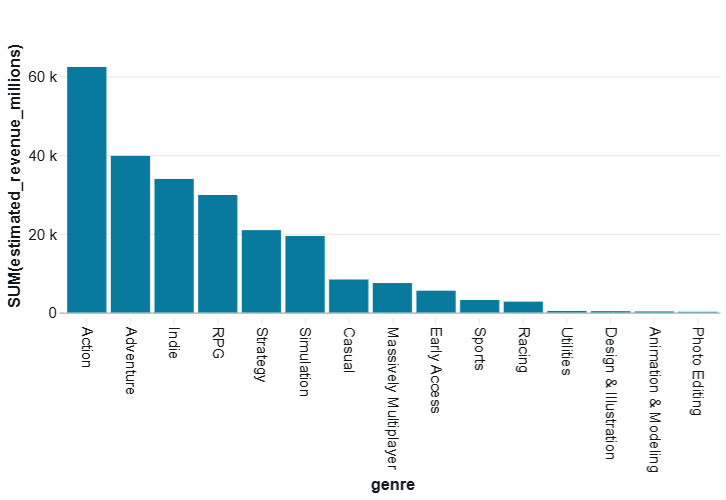

Revenu moyen estimé par jeu, par genre : les genres qui rapportent le plus par jeu ne sont pas forcément ceux qui rapportent le plus au total. Visualisation à créer : barres, axe X = `genre`, axe Y = `revenue_per_game_thousands`.

In [0]:
display(genre_revenue.orderBy(F.desc("revenue_per_game_thousands")).limit(15))

genre,n_games,estimated_revenue_millions,revenue_per_game_thousands
Massively Multiplayer,1460,7498.3,5135.8
RPG,9534,29907.7,3137.0
Action,23759,62498.5,2630.5
Strategy,10895,20966.6,1924.4
Adventure,21431,39865.2,1860.2
Simulation,10836,19482.3,1797.9
Photo Editing,105,175.4,1670.8
Racing,2155,2762.8,1282.0
Sports,2666,3175.1,1191.0
Early Access,6145,5549.8,903.1


## 4. Analyse des plateformes

### Les jeux sont-ils surtout disponibles sur Windows, Mac ou Linux ?

Visualisation à créer : barres, axe X = `platform`, axe Y = `share_of_games`.

In [0]:
n_games_total = games.count()
platforms = games.select(
    F.sum(F.col("platforms.windows").cast("int")).alias("Windows"),
    F.sum(F.col("platforms.mac").cast("int")).alias("Mac"),
    F.sum(F.col("platforms.linux").cast("int")).alias("Linux"),
).collect()[0]

platform_share = spark.createDataFrame(
    [(name, platforms[name], round(platforms[name] / n_games_total, 3)) for name in ["Windows", "Mac", "Linux"]],
    ["platform", "n_games", "share_of_games"],
)
display(platform_share)

platform,n_games,share_of_games
Windows,55675,1.0
Mac,12769,0.229
Linux,8457,0.152


### Certains genres sont-ils plus souvent disponibles sur certaines plateformes ?

Pour les 12 genres les plus représentés : part des jeux disponibles sur chaque plateforme. Visualisation à créer : barres groupées, axe X = `genre`, séries = `platform`, axe Y = `share`.

In [0]:
top12 = [r["genre"] for r in genre_counts.limit(12).collect()]

genre_platforms = (
    game_genres.filter(F.col("genre").isin(top12))
    .groupBy("genre")
    .agg(
        F.avg(F.col("platforms.windows").cast("int")).alias("Windows"),
        F.avg(F.col("platforms.mac").cast("int")).alias("Mac"),
        F.avg(F.col("platforms.linux").cast("int")).alias("Linux"),
    )
)
# une ligne par (genre, plateforme) pour pouvoir faire des barres groupées
genre_platforms_long = genre_platforms.select(
    "genre",
    F.expr("stack(3, 'Windows', Windows, 'Mac', Mac, 'Linux', Linux) as (platform, share)"),
).withColumn("share", F.round("share", 3))
display(genre_platforms_long.orderBy("genre", "platform"))

genre,platform,share
Action,Linux,0.142
Action,Mac,0.192
Action,Windows,1.0
Adventure,Linux,0.154
Adventure,Mac,0.235
Adventure,Windows,1.0
Casual,Linux,0.15
Casual,Mac,0.232
Casual,Windows,1.0
Early Access,Linux,0.103


## 5. Conclusion

Analyse de 55 700 jeux Steam environ.

### Marché global
- Big Fish Games est l'éditeur qui a sorti le plus de jeux (422), devant 8floor (202), SEGA (165) et Strategy First (151). Ubisoft est 9e avec 127 jeux.
- Les jeux les mieux notés (au moins 10 000 avis) dépassent 98 % d'avis positifs : A Short Hike et Aseprite (99,3 %), People Playground, Portal 2 et Hades. Beaucoup viennent de studios indépendants.
- Les sorties ont fortement augmenté : 2 565 jeux en 2015, 8 805 en 2021. Pendant le Covid, 2020 compte 8 287 sorties (+19 % par rapport à 2019, qui avait baissé à 6 949 après 7 663 en 2018), puis 2021 est l'année record. La baisse de 2022 est à prendre avec prudence, l'année pouvant être incomplète.
- Les prix sont bas : 56 % des jeux coûtent moins de 5 (dont 14 % de gratuits), 22 % entre 5 et 10, 16 % entre 10 et 20. Moins de 6 % dépassent 20 et seulement 122 jeux dépassent 60.
- 4,5 % des jeux sont en promotion (2 518 sur 55 690).
- L'anglais est présent dans presque tous les jeux (55 116). Viennent ensuite l'allemand (14 019), le français (13 426), le russe (12 922), le chinois simplifié (12 782) et l'espagnol (12 233).
- Très peu de jeux sont réservés aux adultes : 301 jeux (0,5 %) sont interdits aux moins de 16 ans, dont 225 (0,4 %) aux moins de 18 ans.

### Genres
- Le genre Indie domine (39 681 jeux), suivi d'Action (23 759), Casual (22 086) et Adventure (21 431). Un jeu pouvant avoir plusieurs genres, ces totaux se recoupent.
- Les meilleurs ratios d'avis positifs reviennent aux logiciels créatifs (Photo Editing 97,7 %, Animation & Modeling 96,3 %, Design & Illustration 96,1 %). Parmi les genres de jeux les plus fréquents, Indie (88,5 %) est devant Casual (86,7 %) et Simulation (86,6 %).
- Les éditeurs ont des genres favoris : Big Fish Games, 8floor, HH-Games et Sekai Project publient surtout du Casual, SEGA et Square Enix de l'Action, Choice of Games du RPG et Strategy First de la Stratégie.
- D'après l'estimation du revenu (propriétaires × prix), les genres qui rapportent le plus au total sont Action, Adventure, Indie et RPG. Par jeu, ce sont les jeux massivement multijoueurs (environ 5,1 M par jeu), le RPG (3,1 M) et l'Action (2,6 M) qui rapportent le plus, contre 0,9 M pour l'Indie et 0,4 M pour le Casual : l'Indie et le Casual sont très nombreux mais rapportent peu par jeu.

### Plateformes
- Tous les jeux sont disponibles sur Windows. 22,9 % le sont aussi sur Mac et 15,2 % sur Linux.

### Pistes pour Ubisoft
- Viser les genres qui rapportent le plus par jeu (RPG, Action, multijoueur) plutôt que l'Indie et le Casual, où la concurrence est forte et le revenu moyen faible.
- Prévoir l'anglais en priorité, puis le français, l'allemand, le russe, le chinois simplifié et l'espagnol.
- Windows est indispensable ; Mac et Linux restent minoritaires.
- Le prix médian du marché est bas (moins de 10 pour 78 % des jeux) : un jeu à plus de 30 est rare.

### Limites
- Le revenu est une estimation à partir de fourchettes de propriétaires, sans les remises ni les achats intégrés.
- Les corrélations décrivent le marché mais ne prouvent pas ce qui fait le succès d'un jeu.
- Les chiffres d'un genre se recoupent, car un jeu peut avoir plusieurs genres.